
Logistic Regression
Accuracy: 0.8583
Precision: 0.9412
Recall: 0.6809
F1: 0.7901
ROC-AUC: 0.9592

Decision Tree
Accuracy: 0.8833
Precision: 0.9024
Recall: 0.7872
F1: 0.8409
ROC-AUC: 0.9254

KNN
Accuracy: 0.9167
Precision: 0.8936
Recall: 0.8936
F1: 0.8936
ROC-AUC: 0.9633

SVM
Accuracy: 0.9333
Precision: 0.8980
Recall: 0.9362
F1: 0.9167
ROC-AUC: 0.9764

Stacking Ensemble
Accuracy: 0.9250
Precision: 0.8958
Recall: 0.9149
F1: 0.9053
ROC-AUC: 0.9719


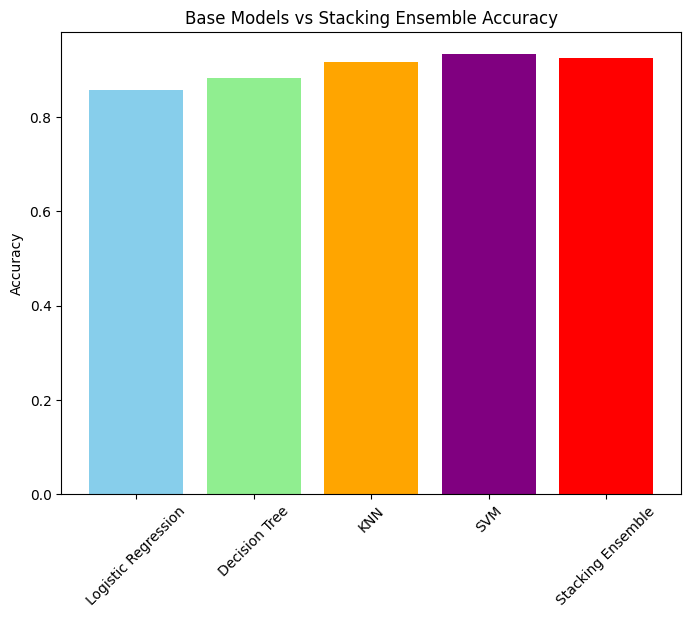

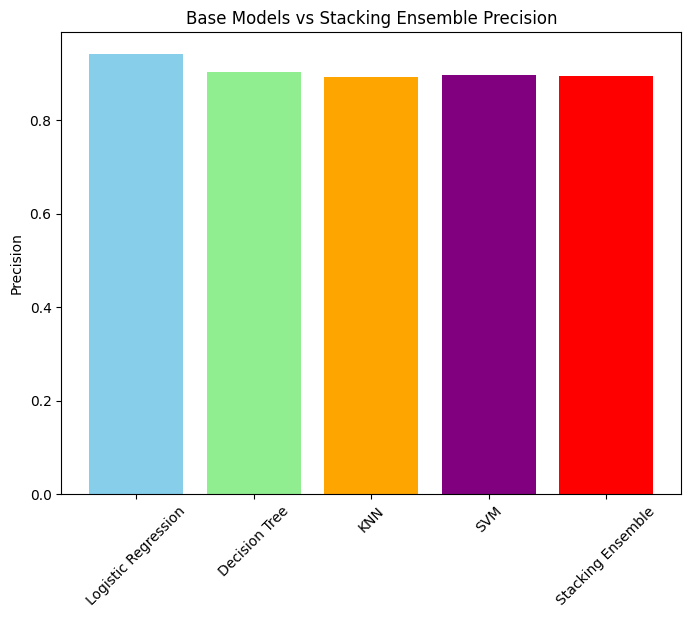

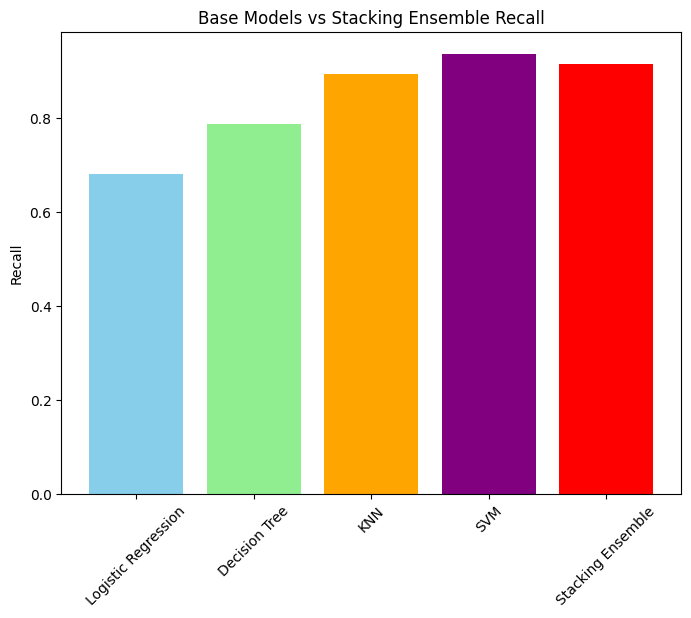

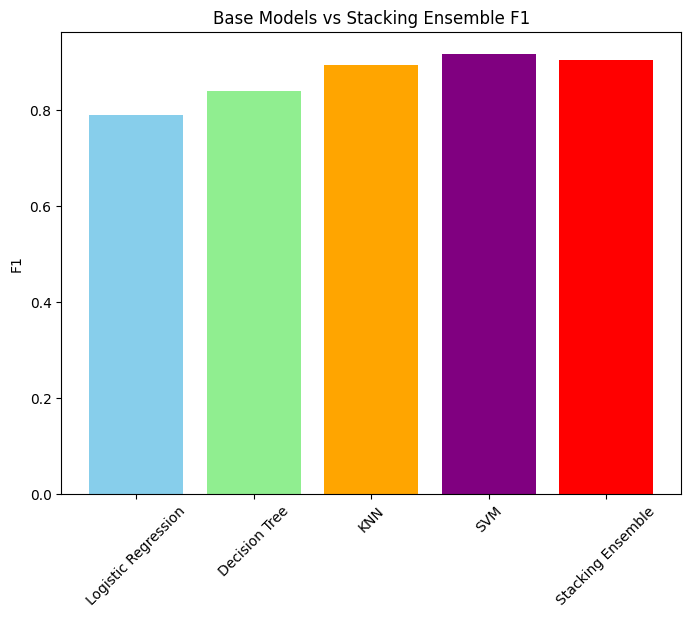

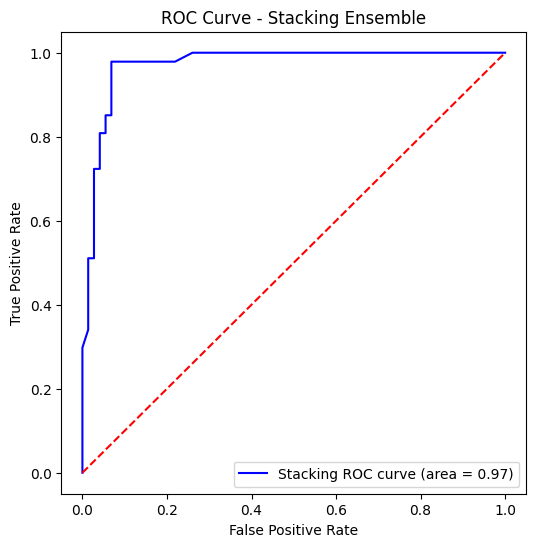

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Advertisements.csv")

# Encode Gender
df['Gender'] = LabelEncoder().fit_transform(df['Gender'])

# Features & Target
X = df[['Gender','Age','EstimatedSalary']]
y = df['Purchased']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Base models
base_models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('Decision Tree', DecisionTreeClassifier(max_depth=5)),
    ('KNN', KNeighborsClassifier(n_neighbors=5)),
    ('SVM', SVC(probability=True))
]

# Stacking Ensemble
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=RandomForestClassifier(n_estimators=100, random_state=42),
    cv=5
)

# Store results
results = {}

# Evaluate base models
for name, model in base_models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }

# Evaluate stacking ensemble
stack_model.fit(X_train, y_train)
y_pred_stack = stack_model.predict(X_test)
y_proba_stack = stack_model.predict_proba(X_test)[:,1]

results['Stacking Ensemble'] = {
    'Accuracy': accuracy_score(y_test, y_pred_stack),
    'Precision': precision_score(y_test, y_pred_stack),
    'Recall': recall_score(y_test, y_pred_stack),
    'F1': f1_score(y_test, y_pred_stack),
    'ROC-AUC': roc_auc_score(y_test, y_proba_stack)
}

# Print results
for model, metrics in results.items():
    print(f"\n{model}")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

# --- Plot Accuracy Comparison ---
plt.figure(figsize=(8,6))
plt.bar(results.keys(), [m['Accuracy'] for m in results.values()], color=['skyblue','lightgreen','orange','purple','red'])
plt.ylabel('Accuracy')
plt.title('Base Models vs Stacking Ensemble Accuracy')
plt.xticks(rotation=45)
plt.show()

# --- Plot Precision, Recall, F1 ---
metrics_list = ['Precision','Recall','F1-Score']
for metric in metrics_list:
    plt.figure(figsize=(8,6))
    plt.bar(results.keys(), [m[metric] for m in results.values()], color=['skyblue','lightgreen','orange','purple','red'])
    plt.ylabel(metric)
    plt.title(f'Base Models vs Stacking Ensemble {metric}')
    plt.xticks(rotation=45)
    plt.show()

# --- ROC Curve for Stacking ---
fpr, tpr, _ = roc_curve(y_test, y_proba_stack)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'Stacking ROC curve (area = {roc_auc:.2f})')
plt.plot([0,1],[0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Stacking Ensemble')
plt.legend(loc="lower right")
plt.show()